In [30]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import math
import os

In [ ]:
partList = ['palm', 'thumb', 'index', 'middle', 'ring', 'pinky' ]
clickLocation = {'col' : 0, 'row': 0, 'hueVal': 0, 'saturVal': 0, 'brightVal':0}
handDict = {}
TEMPLATE_PARTS = {}
SYS_VOCABULARY = ['k', 'b', 'w', 'e']
SIM_THRESHOLD = 22500
MIN_REQ_FRAMES = 2
''' 
-> Class to represent each hand part
    - Parameters : partName (callibration Mode), HSV values 
    - Returns the hand part instance 
'''
class hand_part:
     
    # Initializing the hand_part attributes
    def __init__(self, partName, colorVal):

        

        #Setting up the higher and lower thresholds for current hand part's color range (ensuring value is within  range (0-255 for satur and brightness and 0-179 for hue)) 
        #   +/-  5 hue val 
        #   +/- 20 saturation 
        #   +/- 40 brightness
        self.hsv_low_threshold = np.array([max(0, (colorVal[0] - 5)),
                                           max(0, (colorVal[1] - 20)),
                                           max(0, (colorVal[2] - 40))], dtype= np.uint8)
        
        self.hsv_high_threshold =  np.array([min(179, (colorVal[0] + 5)),
                                             min(255, (colorVal[1] + 20)),
                                             min(255, (colorVal[2] + 40))], dtype= np.uint8)

        self.name = partName        # Part name
        self.color = {'hsv_highT': self.hsv_high_threshold, 'hsv_lowT': self.hsv_low_threshold}     # Color range

        # Attributes initialized at findTipandBase function
        self.region = None      

        if partName == partList[0]:
            self.centerP = None
        else:
            self.baseP = None
            self.tipP = None

        self.visibility = False

            
    ''' 
    --> Function to detect base &tip of the finger
        - Input: current frame, HSV version of current frame, and lower & hogiher hsv threshold values of the tape indicating finger base
        - sets the detected tip & base / center, and region of the finger
    '''
    def findTipandBase(self, curFrame, curFrame_hsv, baseTapeHSV_lowerT, baseTapeHSV_higherT): 

        # Resetting part visibility, coords & region start at each detection
        self.visibility = False
        self.region = None
        if self.name == partList[0]:
            self.centerP = None
        else:
            self.baseP = None
            self.tipP = None

        # Determining the region of of the hand_part by finding the corresponding colored pixels in the current frame
        region_mask = cv2.inRange(curFrame_hsv, self.color['hsv_lowT'], self.color['hsv_highT'])

        tempKernel = np.ones((9,9), dtype= np.uint8)

        # Filling in the holes withing the detected range
        complete_region_mask = cv2.morphologyEx(region_mask, cv2.MORPH_CLOSE , tempKernel, iterations=3)
        
                        
        # Finding contour of correspinding finger region
        ret, binary = cv2.threshold(complete_region_mask, 50, 255, cv2.THRESH_OTSU)
        contourList, hie = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Ensuring at least one contour is found 
        if len(contourList) == 0:
            print(f"Contour list is empty for the part: {self.name}")
            return 

        # Finding the index of contour with max area
        contourAreas = [cv2.contourArea(tempContour) for tempContour in contourList]
        maxAreaContIdx = np.argmax(contourAreas)     
    

        # Filling in the contour with max area
        contour_mask = np.zeros(region_mask.shape, dtype= np.uint8)
        cv2.drawContours(contour_mask, contourList, maxAreaContIdx, 255, -1)

        
        

        self.region = contour_mask  # Assigning part region as filled in max contour to compansate for noise in the initial detection

        # Dilating the contour for it to clearly represent entire finger and cover the finger base as well 
        
        dilated_contour_mask = cv2.dilate(contour_mask, kernel= tempKernel, iterations=1)        


        # Detecting and representing fingers
        if self.name != partList[0]:
            

            # Finding the regions for yellow base tapes
            fingerBase_mask = cv2.inRange(curFrame_hsv, baseTapeHSV_lowerT, baseTapeHSV_higherT)
            # Dilating the contour 
            dilated_fingerBase_mask = cv2.dilate(fingerBase_mask, kernel= tempKernel, iterations=2)

            # ============ finger_base =================
            
            #Finding the base of correponding finger by highlighting the common points in dilated versions of region_mask and fingerBase_mask 
            intersection_mask = (dilated_fingerBase_mask & dilated_contour_mask)    

            
            # Storing the constructed masks
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/region_mask.png', region_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/complete_region_mask.png', complete_region_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/contour_mask.png', contour_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/dilated_contour_mask.png', dilated_contour_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/finger_base_mask.png', fingerBase_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/dilated_fingerBase_mask.png', dilated_fingerBase_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/intersection_mask.png', intersection_mask)

            touchingPointList = []
            for row in range(intersection_mask.shape[0]):       
                for col in range(intersection_mask.shape[1]):

                    curPix = intersection_mask[row][col]

                    # Adding the intersecting point in both masks to touching points list
                    if curPix > 0:
                        touchingPointList.append([row, col])

            # Ensuring touching points found
            if len(touchingPointList) > 0:      

                # finding the middle value of detected base
                finger_base = np.mean(touchingPointList, axis=0)
                #print(f"The {self.name} base found at {finger_base}")
            else:
                print(f"Failed to detect base for {self.name} ")
                return

            # ============== finger_tip ===================
            # Finding all the distances to base within finger range to assign the largest distance as finger_tip
            distList = []
            for row in range(region_mask.shape[0]):       
                for col in range(region_mask.shape[1]):

                    curPix = region_mask[row][col]

                    if curPix > 0:
                        tempD = math.dist(finger_base, (row, col))
                        distList.append({'point': (row, col), 'distance': tempD})

            distList = sorted(distList, key= lambda item : item['distance'], reverse=True)
            finger_tip = distList[0]['point']

            # Setting the finger coordinates
            self.baseP = finger_base
            self.tipP = finger_tip

            if ((self.baseP is not None) and (self.tipP is not None)):
                self.visibility = True

            # Converting finger tip and base values to int ordering for cv2 line format
            finger_base = [int(finger_base[1]), int(finger_base[0]) ]
            finger_tip = [int(finger_tip[1]), int(finger_tip[0]) ]

            if self.visibility == True:
                cv2.circle(curFrame, finger_base, 1, (255,0,0), 2)
                cv2.circle(curFrame, finger_tip, 1, (255,0,0), 2)
                cv2.line(curFrame, finger_base, finger_tip, (0,255,0), 1)
            else:
                print(f"{self.name} is not visible")

        # Detecting and representing palm center
        elif self.name == partList[0]:

            palmRegion_coord = []

            for row in range(region_mask.shape[0]):       
                for col in range(region_mask.shape[1]):
            
                    curPix = region_mask[row][col]
            
                    if curPix > 0:
                        palmRegion_coord.append([row, col])

            #Ensuring palm resion is found
            if len(palmRegion_coord) == 0:
                print(f"{self.name} is not found | aplm coord is empty")
                return

            # Finding the center of palm
            palm_center = np.mean(palmRegion_coord, axis=0)

            #Setting palm center coords
            self.centerP = palm_center

            if self.centerP is not None:
                self.visibility = True

            palm_center = [int(palm_center[1]), int(palm_center[0])]

            if (self.visibility == True):
                cv2.circle(curFrame, palm_center, 1, (0,0,0), 2)
            # Storing the constructed masks
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/region_mask.png', region_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/complete_region_mask.png', complete_region_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/contour_mask.png', contour_mask)
            cv2.imwrite(f'temp_DevImages/masks/{self.name}/dilated_contour_mask.png', dilated_contour_mask)
                      



''' 
Function to transform passed in hand_part region according to the passed in transformation matrix.
--> Thiss allows to align the captured gestrue with mask to create and compare gesture tempaltes
'''   
def warping_affine(transofrmationatrix, curRegion, output_H, output_W):

    result = np.zeros((output_H, output_W), dtype= curRegion.dtype)

    row, col = curRegion.shape

    matrix_inv = np.linalg.inv(transofrmationatrix)

    for curRow in range(output_H):
        for curCol in range(output_W):

            # Finding corresponding point after transformation
            curP = matrix_inv @ np.array([curCol, curRow, 1])
            curP = curP.astype('int')

            curP_acutal_row = curP[1]
            curP_acutal_col = curP[0]

            # Continue (skipping point) if coordinates does NOT correspond to orginial img or if they are below 0
            if ( (curP_acutal_row >= row) or (curP_acutal_col >= col) or (curP_acutal_row < 0) or (curP_acutal_col < 0) ):
                continue

            # Constucting the transformation result
            result[curRow][curCol] = curRegion[curP_acutal_row][curP_acutal_col]

    return result


''' 
--> Class to represent the complete hand . Constructed using each hand part individually
    - thumb
    - index finger
    - middle finger
    - ring finger
    - pinky finger
    - palm
'''
class hand:
    def __init__(self, thumb, index, middle, ring, pinky, palm):

        self.palm = palm
        self.thumb = thumb
        self.indexFinger = index
        self.middleFinger = middle
        self.ringFinger = ring
        self.pinkyFinger = pinky
        

    def iterateHand(self):
        return [self.palm, self.thumb, self.indexFinger, self.middleFinger, self.ringFinger, self.pinkyFinger]

    ''' 
        Function to normalize hand and create a comparable and color-coded represntation of the cpatured complete hand. Overall structure
            1- Create a mask to store the result gesture template --> gesture_mask
            2- Apply scale transformation
                - Calculate palm_width to determine scale ratio by --> target Palm Wdith / current palm width
            3- Apply translation transformation
                - Calcualte the row & col translation by --> target origin - current origin(after scaling)
            5- Cosntuct the complete hand using the transformed regions and selected colors 
                
    '''
    def normalizeHand(self):

        # Creating a 400x400 3 channeled mask to represent normalized complete hand with seperate colors
        mask_width = 400
        mask_height = 400
        gesture_Mask = np.zeros([mask_height,mask_width, 3], dtype= np.uint8)

        maskOrigin_row = 300
        maskOrigin_col = 200 
        maskTargetPalmWidth = 200

        # Enusring palm in complete hand is detected
        if ((self.palm.region is None) or (self.palm.visibility == False) or (self.palm.centerP is None)):
            print("Hand normalization failed | Palm NOT found")
            return


        # Going thourgh the palm region to determine columns represnting palm
        palmColList = []
        for row in range(self.palm.region.shape[0]):       
            for col in range(self.palm.region.shape[1]):
        
                curPix = self.palm.region[row][col]
        
                if curPix > 0:
                    palmColList.append(col)

        if len(palmColList) == 0:
            print(f"Normalziation faled. Palm width can NOT be found")
            return

        # Setting the palm width and origin point in the unprocessed frame

        curPalmWidth = max(palmColList) - min(palmColList)     # width as the difference of largest and smallest col values

        if curPalmWidth == 0:
            print("Can NOT normalize | Palm width is 0")
            return

        # Determining the scale ratio to match the mask size and captured gasture size
        scale_ratio = maskTargetPalmWidth / curPalmWidth

        curOrigin = self.palm.centerP          # origin as the palm cetner

        # Finding the oirgin point after scaling to cetner the mask palm appropriately
        scaled_curOrigin_col = int(curOrigin[1] * scale_ratio)
        scaled_curOrigin_row = int(curOrigin[0] * scale_ratio)
                
        # Determining transition values to align the mask and captured gesture
        t_col = maskOrigin_col - scaled_curOrigin_col
        t_row = maskOrigin_row - scaled_curOrigin_row

        # Combining scaling andtranslation transofmation in 1 matrix
        T_transformation = np.array( [[scale_ratio, 0, t_col],
                                     [0, scale_ratio, t_row],
                                     [0, 0, 1]])

        transformed_handParts = {}
        tempPartList = self.iterateHand()
        for part in tempPartList:
            if ((part.visibility == True) and (part.region is not None)):
                transformed_handParts[part.name] = warping_affine(T_transformation, part.region, mask_height, mask_width)
            else:
                print(f"{part.name} is not visible or region is empty")

        # Setting colors(BGR values) for each part 
        ''' 
        Respectievely same colors with the glove used while developing
        palm - grey (becasue ackground is black)
        thumb - pink
        index - orange
        middle - light blue
        ring - green
        pinky - purple
        '''
        partColors = {
            'palm' : (150,150,150),
            'thumb' : (200,200,255),
            'index' : (0, 165, 255),
            'middle' : (255,0,0),
            'ring' : (0, 255, 0),
            'pinky' : (200, 50 ,150)
        }

        # Filling up the gesture_mask based on partColors and transformed_handParts (which represnets the transofrmed region mask for each visible part)
        for partKey in transformed_handParts.keys():
                tempRow = transformed_handParts[partKey].shape[0]
                tempCol = transformed_handParts[partKey].shape[1]

                curPix_color = partColors[partKey]

                for row in range(tempRow):
                    for col in range(tempCol):

                        tempPix = transformed_handParts[partKey][row][col]

                        if ( (tempPix > 0) and ( (row < gesture_Mask.shape[0]) and (col < gesture_Mask.shape[1]) ) ):
                        
                            gesture_Mask[row][col] = curPix_color

        cv2.imwrite('temp_DevImages/complete_hand.png', gesture_Mask)

        return gesture_Mask, transformed_handParts 



        

    



'''
 Function to process left-mouse click. The function
 1- Captures a small pixel area around the clicked pixel 
 2- Computes the average hsv values of shighlighted area (hue, saturation, brightness)
 3- Created the corresponding hand part according to the color values computed on step-2 & current calibration state at the time user clicked

'''
def process_click(click, col, row, flags, param):
    
    global baseTapeHSV_lowT, baseTapeHSV_highT 

    if click == cv2.EVENT_LBUTTONDOWN:

        clickLocation['col'] = col
        clickLocation['row'] = row

        print("Left click detected at coordinates\n x - ", col, "\ny - ", row)
        
        # Selecting a small area around the click positions
        tempArea = param[ row -2 : row+2, col-3 : col+3]
        
        # Computing the set of average HSV values 
        clicked_HSV = np.mean(tempArea, axis=(0,1))

        if calibMode == 'finger_base':

            #Setting up the higher and lower thresholds for finger_base tape (ensuring value is within range (0-255 for satur and brightness and 0-179 for hue)) 
            #   +/-  5 hue val 
            #   +/- 60 saturation 
            #   +/- 70 brightness
                    
            baseTapeHSV_lowT = np.array([max(0, (clicked_HSV[0] - 5)),
                                            max(0, (clicked_HSV[1] - 60)),
                                            max(0, (clicked_HSV[2] - 70))], dtype= np.uint8)
                    
            baseTapeHSV_highT =  np.array([ min(179, (clicked_HSV[0] + 5)),
                                            min(255, (clicked_HSV[1] + 60)),
                                            min(255, (clicked_HSV[2] + 70))], dtype= np.uint8)

            print(f"Finger base tape values:\nLower Threshold -> {baseTapeHSV_lowT}\nHigher Threshold -> {baseTapeHSV_highT}")
        
            
        else:
            

            clickLocation['col'] = col
            clickLocation['row'] = row
            clickLocation['hueVal'] = clicked_HSV[0]
            clickLocation['saturVal'] = clicked_HSV[1]
            clickLocation['brightVal'] = clicked_HSV[2]

            if calibMode != 'Not Selected':

                # Constructing the hand part with corresponding color
                tempPart = hand_part(calibMode, clicked_HSV)

                # Adding the constructed hand part to the global hand dictionary
                handDict[calibMode] = tempPart

                print(f"Object {calibMode} created and added to dict!")


            #clicked_HSV = curFrame[row, col]
            print(f"Hand Part: {calibMode}\nHSV value at clicked location - {clicked_HSV}\nColor(Hue) Value: {clicked_HSV[0]}")



def find_active_coords_rgb(mask):

    coordList = []

    for row in range(mask.shape[0]):
        for col in range(mask.shape[1]):

            curPix = mask[row][col]

            if curPix[0] > 0 or curPix[1] > 0 or curPix[2] > 0 :
                coordList.append((row, col))

    return coordList

def find_gesture(curGestureMask, curHand_part_region_list):

    vocabSimList = []
    
    curGestureMaskCoords = find_active_coords_rgb(curGestureMask)


    for char in TEMPLATE_LIST.keys():

        curGestureMaskPixList = []
        curTemplatePixList = []
        totActiveCoords = []

        

        curTemplate = TEMPLATE_LIST[char]

        if curTemplate is None:
            print(f"Template can NOT be found for:  {char}")
            continue

        curTemplateCoords = find_active_coords_rgb(curTemplate)


        # Combining all active points to ensure all active point on each image is compared 
        totActiveCoords = curGestureMaskCoords + curTemplateCoords

        # Removing duplicates 
        totActiveCoords = list(set(totActiveCoords))

        #Ensuring active coords list is not empty
        if len(totActiveCoords) == 0:
            print("Total active coords length is 0")
            continue

        # Retrieving all the pixels to compare from both masks
        for row, col in totActiveCoords:
            curGestureMaskPixList.append(curGestureMask[row][col])
            curTemplatePixList.append(curTemplate[row][col])  

        curGestureMaskPixList = np.array(curGestureMaskPixList, dtype= 'float')
        curTemplatePixList = np.array(curTemplatePixList, dtype= 'float')

        tempScore = np.mean((curGestureMaskPixList - curTemplatePixList) ** 2)     # Computing mse(mean squared error) as similarty between current template and passed in gesture mask & normalize it

        # Finding visible parts of current mask
        tempCurVisibleParts = []
        tempDiff = 0
        for partName in curHand_part_region_list.keys():
            tempCurVisibleParts.append(partName)

        # Comparing the visible parts of template and current mask, if different penalzie by 200 per misatch

        # Visible in current gesture but shouddnt be 
        for part in tempCurVisibleParts:
            if part not in TEMPLATE_PARTS[char]:
                tempDiff += 1
        # Should be visible in current gesture but isnt
        for part in TEMPLATE_PARTS[char]:
            if part not in tempCurVisibleParts:
                tempDiff += 1        
        
        tempScore += (200* tempDiff)
        tempEntry = {'char' : char, 'simScore': tempScore}

        vocabSimList.append(tempEntry)

        #print(f"{char} - Sim score: {simScore}")
    return vocabSimList
    

**CALIBRATION**
- 


In [32]:


flag = True
display_manual = False
calibMode = 'Not Selected'
baseTapeHSV_lowT = None
baseTapeHSV_highT = None
complete_hand = None


# Opening the defult webcam
webcam = cv2.VideoCapture(0)

if webcam.isOpened():
    print("Webcam is open & reading")
else:
    print("Can NOT access th webcam")


# Retrieving the display size of the webcam
frame_w = int(webcam.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(webcam.get(cv2.CAP_PROP_FRAME_HEIGHT))

#print("Webcam Dimensions\nWidth: ", frame_w, "\nHieght: ", frame_h)

# Creating a video writer to save the ouput video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
result = cv2.VideoWriter('callibration.mp4', fourcc, 30.0, frameSize=(frame_w, frame_h))


while flag:
    
    # Reading the current frame
    ret, curFrame = webcam.read()

    
    # Stopping the video capture if frame read failed
    if not ret:
        print("Frame can NOT be read")
        flag = False
        break

    # Converting frame to HSV format to get more distinct set of values relative to standard bgr
    curFrame_hsv = cv2.cvtColor(curFrame, cv2.COLOR_BGR2HSV)
    
    # Processing the frame

    # ------------------ Calibrating mode   -------------------
    text = (f'Current calibration mode: {calibMode}')
    cv2.putText(curFrame, 'Press [m] to toggle manual', (2,30),cv2.FONT_HERSHEY_PLAIN, 1, (0,0,255), 1)
    cv2.putText(curFrame, text, (2,60),cv2.FONT_HERSHEY_PLAIN, 1, (0,0,255), 1)

    if display_manual:

        tempRow = 80

        for part in partList:

            match part:
                case 'thumb':
                    manual = (f"[a] - {part}")
                    tempRow += 20

                case 'index':
                    manual = (f"[s] - {part}")
                    tempRow += 20

                case 'middle':
                    manual = (f"[d] - {part}")
                    tempRow += 20   

                case 'ring':
                    manual = (f"[f] - {part}")
                    tempRow += 20

                case 'pinky':
                    manual = (f"[g] - {part}")
                    tempRow += 20

                case 'palm':
                    manual = (f"[h] - {part}")
                    tempRow += 20


            cv2.putText(curFrame, manual, (2,tempRow),cv2.FONT_HERSHEY_PLAIN, 1, (0,255, 0), 1)
    
    # Dispalying & calibrating handparts on the webcam view
    for key in handDict.keys():
        if (baseTapeHSV_lowT is not None and baseTapeHSV_highT is not None ):
            handDict[key].findTipandBase(curFrame, curFrame_hsv, baseTapeHSV_lowT, baseTapeHSV_highT)
        else:
            print("Base tape threshold detection failed")
            
    
    cv2.imshow('Sign_Match WebCam View', curFrame)
    
    ''' 
    Setting mouse click to call process_click -> 
        - captures the average HSV values of the small area around the click position 
        - constructs the corresponding hand_part instance with captued color
    '''
    cv2.setMouseCallback('Sign_Match WebCam View', process_click, param = curFrame_hsv)

    

    # Constructing the complete hand when all main hand parts are detected
    if len(handDict.keys()) == 6 and complete_hand is None:
                            
        complete_hand = hand(handDict[partList[1]], 
                            handDict[partList[2]], 
                            handDict[partList[3]], 
                            handDict[partList[4]], 
                            handDict[partList[5]], 
                            handDict[partList[0]]) 

    if complete_hand is not None:
        complete_hand.normalizeHand()
        flag = False
        break
    

    
    # Setting the pressed key actions
    pressedKey = cv2.waitKey(1)

    # Exitting the webcam when the key 'q' is pressed
    if pressedKey == ord('q'):
        flag = False
    # Toggleing the manual display on screem when the key 'm' is pressed
    if pressedKey == ord('m'):
        display_manual = not display_manual
    # Setting calibration mode for thumb
    if pressedKey == ord('a'):
        calibMode = partList[1]
    # Setting calibration mode for index
    if pressedKey == ord('s'):
        calibMode = partList[2]
    # Setting calibration mode for middle
    if pressedKey == ord('d'):
        calibMode = partList[3]
    # Setting calibration mode for ring
    if pressedKey == ord('f'):
        calibMode = partList[4]
    # Setting calibration mode for pinky
    if pressedKey == ord('g'):
        calibMode = partList[5]
    # Setting calibration mode for palm
    if pressedKey == ord('h'):
        calibMode = partList[0]
    # Setting calibration mode for tape indicating finger base
    if pressedKey == ord('y'):
        calibMode = 'finger_base'
        
    
    
    

    # Saving the webcam footage as result video
    result.write(curFrame)

# Releasing the resources
webcam.release()
result.release()
cv2.destroyAllWindows()






Webcam is open & reading
Left click detected at coordinates
 x -  220 
y -  290
Finger base tape values:
Lower Threshold -> [21 65 82]
Higher Threshold -> [ 31 185 222]
Left click detected at coordinates
 x -  183 
y -  260
Object thumb created and added to dict!
Hand Part: thumb
HSV value at clicked location - [171.125 122.25  183.   ]
Color(Hue) Value: 171.125
Left click detected at coordinates
 x -  239 
y -  171
Object index created and added to dict!
Hand Part: index
HSV value at clicked location - [  9.41666667 154.41666667 161.29166667]
Color(Hue) Value: 9.416666666666666
Left click detected at coordinates
 x -  284 
y -  156
Object middle created and added to dict!
Hand Part: middle
HSV value at clicked location - [106.20833333 188.58333333 148.        ]
Color(Hue) Value: 106.20833333333333
Left click detected at coordinates
 x -  326 
y -  163
Object ring created and added to dict!
Hand Part: ring
HSV value at clicked location - [79.79166667 83.25       64.04166667]
Color(Hue)

**Saving raw represtations of each gesture**
-

In [39]:


# Opening the defult webcam
template_flag = True
webcam = cv2.VideoCapture(0)

if webcam.isOpened():
    print("Webcam is open & reading")
else:
    print("Can NOT access th webcam")


# Retrieving the display size of the webcam
frame_w = int(webcam.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(webcam.get(cv2.CAP_PROP_FRAME_HEIGHT))

#print("Webcam Dimensions\nWidth: ", frame_w, "\nHieght: ", frame_h)



while template_flag:
    
    # Reading the current frame
    ret, curFrame = webcam.read()


    # Stopping the video capture if frame read failed
    if not ret:
        print("Frame can NOT be read")
        template_flag = False
        break


    # Setting the pressed key actions
    pressedKey = cv2.waitKey(1)



    # Saving the entered chars raw template

    if pressedKey == ord('i'):

        gestureName = 'i'
        rawTemaplate_path = f"gesture_templates/raw/raw_{gestureName}_template.png"
        cv2.imwrite(rawTemaplate_path, curFrame)
    if pressedKey == ord('k'):

        gestureName = 'k'
        rawTemaplate_path = f"gesture_templates/raw/raw_{gestureName}_template.png"
        cv2.imwrite(rawTemaplate_path, curFrame)
    if pressedKey == ord('b'):

        gestureName = 'b'
        rawTemaplate_path = f"gesture_templates/raw/raw_{gestureName}_template.png"
        cv2.imwrite(rawTemaplate_path, curFrame)
    if pressedKey == ord('e'):

        gestureName = 'e'
        rawTemaplate_path = f"gesture_templates/raw/raw_{gestureName}_template.png"
        cv2.imwrite(rawTemaplate_path, curFrame)

    if pressedKey == ord('w'):

        gestureName = 'w'
        rawTemaplate_path = f"gesture_templates/raw/raw_{gestureName}_template.png"
        cv2.imwrite(rawTemaplate_path, curFrame)

    # Exitting the webcam when the key 'q' is pressed
    if pressedKey == ord('q'):
        template_flag = False



    cv2.imshow('Temp - tempalte saving view', curFrame)

    
    


webcam.release()
cv2.destroyAllWindows()







Webcam is open & reading


**NORMALIZING THE  RAW GESTURES**
-

In [42]:

gestureName = 'w'
rawTemplate = cv2.imread(f'gesture_templates/raw/raw_{gestureName}_template.png')
rawTemplate_hsv = cv2.cvtColor(rawTemplate, cv2.COLOR_BGR2HSV)

for key in handDict.keys():
    if (baseTapeHSV_lowT is not None and baseTapeHSV_highT is not None ):
        handDict[key].findTipandBase(rawTemplate, rawTemplate_hsv, baseTapeHSV_lowT, baseTapeHSV_highT)
    else:
        print("Base tape threshold detection failed")

# Constructing the complete hand when all main hand parts are detected
if len(handDict.keys()) == 6 and complete_hand is None:
                                
    complete_hand = hand(handDict[partList[1]], 
                        handDict[partList[2]], 
                        handDict[partList[3]], 
                        handDict[partList[4]], 
                        handDict[partList[5]], 
                        handDict[partList[0]]) 
    
if complete_hand is not None:
    curGesture, curHand_part_list = complete_hand.normalizeHand()

outputPath = f'gesture_templates/normalized/norm_{gestureName}_template.png'
cv2.imwrite(outputPath, curGesture)

tempList = []
for partName in curHand_part_list.keys():
    tempList.append(partName)

TEMPLATE_PARTS[gestureName] = tempList

Failed to detect base for pinky 
pinky is not visible or region is empty


**SAVING INPUT VIDEO**
-
**Run this block & adjust the 'inputVidRecorder' path to record a new video (press q to end the video)**

In [43]:
# Opening the defult webcam
tempFlag = True
webcam = cv2.VideoCapture(0)

if webcam.isOpened():
    print("Webcam is open & reading")
else:
    print("Can NOT access th webcam")


# Retrieving the display size of the webcam
frame_w = int(webcam.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(webcam.get(cv2.CAP_PROP_FRAME_HEIGHT))

#print("Webcam Dimensions\nWidth: ", frame_w, "\nHieght: ", frame_h)

# Creating a video writer to save the ouput video
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
inputVidRecorder = cv2.VideoWriter('inputVids/input_videoDemo.mp4', fourcc, 30.0, frameSize=(frame_w, frame_h))

while tempFlag:
    
    # Reading the current frame
    ret, curFrame = webcam.read()


    # Stopping the video capture if frame read failed
    if not ret:
        print("Frame can NOT be read")
        tempFlag = False
        break

    # Setting the pressed key actions
    pressedKey = cv2.waitKey(1)

    # Exitting the webcam when the key 'q' is pressed
    if pressedKey == ord('q'):
        tempFlag = False    

    inputVidRecorder.write(curFrame)
    cv2.imshow('Saving Input Video', curFrame)

# Releasing the resources
webcam.release()
inputVidRecorder.release()
cv2.destroyAllWindows()

Webcam is open & reading


**MAIN INPUT VIDEO**
-

In [ ]:
TEMPLATE_LIST = {
    
    'k' : cv2.imread(f"gesture_templates/normalized/norm_k_template.png"),
    'b' : cv2.imread(f"gesture_templates/normalized/norm_b_template.png"),
    'w' : cv2.imread(f"gesture_templates/normalized/norm_w_template.png"),
    'e' : cv2.imread(f"gesture_templates/normalized/norm_e_template.png")
    
}
TEMPLATE_PARTS = {

    'k' : ['palm', 'thumb', 'index', 'middle'],
    'b' : ['palm', 'thumb', 'index', 'middle', 'ring', 'pinky'],
    'w' : ['palm', 'thumb', 'index', 'middle', 'ring'],
    'e' : ['palm', 'thumb', 'index', 'middle', 'ring', 'pinky']
    }


In [ ]:


def sign_match_ASL(inputVidPath, vidNo):


    global complete_hand

    inputVid = cv2.VideoCapture(inputVidPath)


    tempDebug = []
    result = []
    lastMatch = None
    matchCount = 1
    videoFlag = True
    tempCount = 0

    # Retrieving the display size of the webcam
    frame_w = int(inputVid.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_h = int(inputVid.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    resultVid = cv2.VideoWriter(f'resultVids/result{vidNo}.mp4', fourcc, 30.0, frameSize=(frame_w, frame_h))

    while(videoFlag):
        
        

        tempVocabSimList = []

        # Variable to store normalized hand gesture at each frame
        curGesture = None
        curHand_part_masks = None

        ret, frame = inputVid.read()

        if not ret:
            print("Input video can not be read")
            videoFlag = False
            break

        matchedGesture = None
        tempCount += 1

        # Processing only every 5 frame to make it faster
        if tempCount % 5 != 0:
                continue

        
        curFrame_hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

        for key in handDict.keys():
            if (baseTapeHSV_lowT is not None and baseTapeHSV_highT is not None ):
                handDict[key].findTipandBase(frame, curFrame_hsv, baseTapeHSV_lowT, baseTapeHSV_highT)
            else:
                print("Base tape threshold detection failed")
                videoFlag = False
                break

        # Constructing the complete hand when all main hand parts are detected
        if len(handDict.keys()) == 6 and complete_hand is None:
                                    
            complete_hand = hand(handDict[partList[1]], 
                                handDict[partList[2]], 
                                handDict[partList[3]], 
                                handDict[partList[4]], 
                                handDict[partList[5]], 
                                handDict[partList[0]]) 
        
        if complete_hand is not None:

            tempNormResult = complete_hand.normalizeHand()

            if tempNormResult is None:
                print(f"Frame #{tempCount} can not be normalized")
                continue
            curGesture, curHand_part_region_list = tempNormResult

        if curGesture is None:
            print("Current frame can NOT be normalized")
            continue

        tempVocabSimList = find_gesture(curGesture, curHand_part_region_list)

        if len(tempVocabSimList) == 0:
            print("find_gesture() function failed")
            continue
            

        sorted_tempVocabSimList = sorted(tempVocabSimList, key= lambda sim : sim['simScore'])

        matchedGesture = sorted_tempVocabSimList[0]

        # Including only matches below a threshold ( lower mse score means more similar)
        if matchedGesture['simScore'] < SIM_THRESHOLD:

            # Counting the frames the character consistently detected for
            if matchedGesture['char'] == lastMatch:
                matchCount += 1
            else:
                lastMatch = matchedGesture['char']
                matchCount = 1
        else:
            lastMatch = None
            matchCount = 1
            


        #print(f"Fr #{tempCount}     -     {matchedGesture['char']}")

        tempDebug.append({'frameNo': tempCount , 'scoreList' :sorted_tempVocabSimList})

        if matchCount == MIN_REQ_FRAMES:
            result.append({'char' : matchedGesture['char'], 'score' : matchedGesture['simScore'], 'frameNo' : tempCount, 'frame' : frame})
        elif matchCount > MIN_REQ_FRAMES:
            continue

        cv2.putText(frame, f"Current Match: {matchedGesture['char']} ", (2,30),cv2.FONT_HERSHEY_PLAIN, 1, (0,0,255), 1)

        resultVid.write(frame)

    inputVid.release()
    resultVid.release()
    cv2.destroyAllWindows()

    return result, tempDebug


    
        

**TEST & DISPLAY RESULTS**
-

Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Failed to detect base for pinky 
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Failed to detect base for ring 
Contour list is empty for the part: pinky
ring is not visible or region is empty
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Failed to detect base for ring 
Contour list is empty for the part: pinky
ring is not visible or region is empty
pinky is not visible or region is empty
Failed to detect base for ring 
Contour list is empty for the part: pinky
ring is not visible or region is empty
pinky is not visible or region is empty
Failed to detect base for ring 
Contour list is empty for 

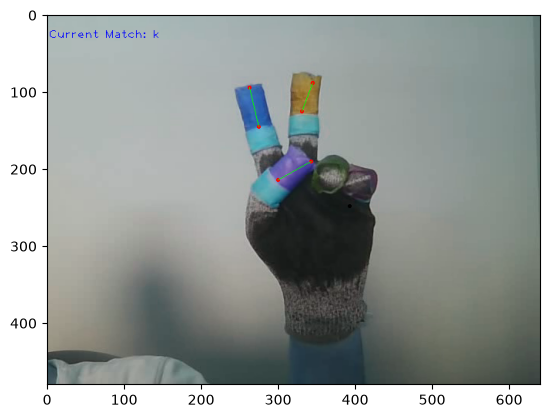

In [68]:

inputVidPath_1 = 'inputVids/input_video1.mp4'
vid1Res, tepDebug1 = sign_match_ASL(inputVidPath_1, 1)

print(f"Size of video 1 result with sim Threshold: {SIM_THRESHOLD} is --> {len(vid1Res)}\nResult:\n")
for val in vid1Res:
    print(f"Frame #{val['frameNo']} --> {val['char']} | {val['score']}")
    plt.imshow(val['frame'])
    plt.show()

Failed to detect base for pinky 
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for

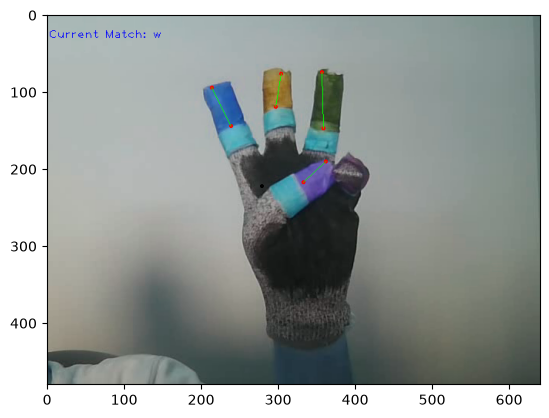

Frame #420 --> w | 22130.69890152417


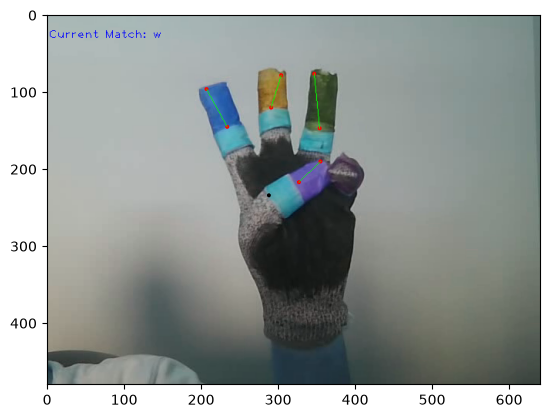

In [75]:
inputVidPath_2 = 'inputVids/input_video2.mp4'
vid2Res, tempDebub2 = sign_match_ASL(inputVidPath_2, 2)

print(f"Size of video 2 result with sim Threshold: {SIM_THRESHOLD} is --> {len(vid2Res)}\nResult: \n")
for val in vid2Res:
    print(f"Frame #{val['frameNo']} --> {val['char']} | {val['score']}")
    plt.imshow(val['frame'])
    plt.show()

In [76]:

inputVidPath_3 = 'inputVids/input_video3.mp4'
vid3Res, tempDebug3 = sign_match_ASL(inputVidPath_3, 3)

print(f"Size of video 3 result with sim Threshold: {SIM_THRESHOLD} is --> {len(vid3Res)}\nResult:\n")
for val in vid3Res:
    print(f"Frame #{val['frameNo']} --> {val['char']} | {val['score']}")
    plt.imshow(val['frame'])
    plt.show()

Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is empty for the part: pinky
pinky is not visible or region is empty
Contour list is 

Failed to detect base for thumb 
thumb is not visible or region is empty
Failed to detect base for thumb 
thumb is not visible or region is empty
Failed to detect base for thumb 
thumb is not visible or region is empty
Failed to detect base for thumb 
thumb is not visible or region is empty
Failed to detect base for thumb 
thumb is not visible or region is empty
Failed to detect base for index 
Failed to detect base for middle 
Failed to detect base for ring 
Contour list is empty for the part: pinky
index is not visible or region is empty
middle is not visible or region is empty
ring is not visible or region is empty
pinky is not visible or region is empty
Failed to detect base for index 
Contour list is empty for the part: middle
Failed to detect base for ring 
Failed to detect base for pinky 
index is not visible or region is empty
middle is not visible or region is empty
ring is not visible or region is empty
pinky is not visible or region is empty
Failed to detect base for index 


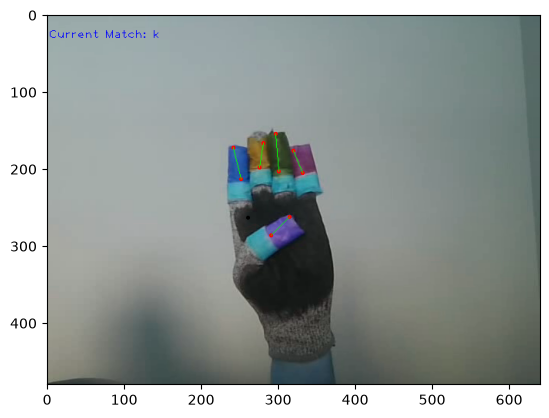

In [77]:
inputVidPath_4 = 'inputVids/input_video4.mp4'
vid4Res, tempDebug4 = sign_match_ASL(inputVidPath_4, 4)

print(f"Size of video 4 result with sim Threshold: {SIM_THRESHOLD} is --> {len(vid4Res)}\nResult:\n")
for val in vid4Res:
    print(f"Frame #{val['frameNo']} --> {val['char']} | {val['score']}")
    plt.imshow(val['frame'])
    plt.show()

**DEBUGGING**
-

In [ ]:
y = 0
print(len(tepDebug1))
for y in range(len(tepDebug1)):
    y += 1

    if y % 50 != 0:
        continue

    print(f"{tepDebug1[y]} \n")